In [1]:
import random
import matplotlib.pyplot as plt
from src.preprocessing import *
from src.utils import *
from pathlib import Path

In [2]:
# Group all paths by serie and pick one randomly to test
paths = get_all_image_paths()
series = group_paths_by_serie(paths)
print(f"Total series found: {len(series)}")

SEED = 55

Total images found: 8325
Total series found: 214


## Step 1 — Background Subtraction
Before CLAHE, we remove the slow-varying background illumination (ribcage, diaphragm, soft tissue gradients) using a large Gaussian blur:

```
background = GaussianBlur(image, large_kernel)
residual   = image − background   → vessels on a flat background
output     = rescale to [0, 255]  → ready for CLAHE
```

Use the **kernel size** slider to control how aggressively the background is estimated.
- Too small → vessels start getting absorbed into the background estimate
- Too large → background not fully removed, uneven illumination remains
- Sweet spot → flat grey background with vessels clearly standing out

In [3]:
browse_background_grid(series, n=9, seed=SEED)

#save_single(series,"outputImages/bs", lambda img: subtract_background(img, kernel_size=21), positions = [2,7], seed = SEED,dpi = 300)

interactive(children=(IntSlider(value=21, description='Kernel size', layout=Layout(width='500px'), max=201, mi…

##  Step 2 — CLAHE
Apply CLAHE using different clip limits to see the effect on contrast enhancement. The clip limit controls how much the histogram is allowed to be amplified, which can help prevent over-enhancement of noise in homogeneous areas.

for row, idx in enumerate(indices_to_show):
    r = results[idx]

A 3×3 grid of **one middle frame per patient** (randomly selected).
Use the single slider to adjust the clip limit and assess which value generalises best across different patients — left column is always the original, right column the CLAHE result.

In [ ]:
KERNEL_SIZE = 121  # adjust manually and re-run

browse_bg_clahe_grid(series, kernel_size=KERNEL_SIZE, n=9, seed=SEED)

#save_single(series,"outputImages/clahe", lambda img: apply_clahe(subtract_background(img, kernel_size=KERNEL_SIZE), clip_limit=5.0),positions = [2,7], seed = SEED, dpi = 300)

interactive(children=(FloatSlider(value=2.0, description='Clip limit', layout=Layout(width='450px'), max=10.0,…

## Step 3 — NLM Filtering
BG subtraction and CLAHE are fixed from the steps above — set `KERNEL_SIZE` and `CLIP_LIMIT` to match.

NLM has three parameters to tune:
- **h** — filter strength: the main knob. Higher = more smoothing, more vessel edge loss. Try 5–15.
- **Template window** — patch size for comparing pixel similarity (must be odd). Default 7 is usually fine.
- **Search window** — area searched for similar patches (must be odd). Larger = better but slower. Default 21 is usually fine.

Start by tuning **h** with template/search windows at defaults, then adjust the others only if needed.

In [ ]:
KERNEL_SIZE = 61  # adjust manually and re-run
CLIP_LIMIT  = 4.0  # must match the value used in Step 3
browse_nlm_grid(series, kernel_size=KERNEL_SIZE, clip_limit=CLIP_LIMIT, n=9, seed=SEED)

interactive(children=(IntSlider(value=10, description='h (filter strength)', layout=Layout(width='450px'), max…

In [6]:
H = 19

save_single(series,"outputImages/bs_clahe_nlm",
            lambda img: apply_nlm(
                        apply_clahe(
                        subtract_background(img, kernel_size=KERNEL_SIZE), clip_limit=CLIP_LIMIT), h=H), positions = [5,7], seed = SEED, dpi = 300)

  Saved → outputImages\bs_clahe_nlm\P076.png
  Saved → outputImages\bs_clahe_nlm\P085.png


## Step 3b — Bilateral Filtering (alternative to NLM)
Same fixed BG subtraction + CLAHE as above. Three parameters to tune:

- **d** — neighborhood diameter. Higher = larger area considered per pixel.
- **sigma_color** — intensity tolerance. Low = only very similar intensities averaged (edge-preserving). High = smoother but edges start blurring.
- **sigma_space** — spatial tolerance. Higher = farther pixels contribute more.

A good starting point is d=9, sigma_color=75, sigma_space=75. Raise sigma_color to increase smoothing; lower it to preserve more vessel edge detail.

In [7]:
# Use the same NLM parameters to compare results.
KERNEL_SIZE = KERNEL_SIZE
CLIP_LIMIT  = CLIP_LIMIT
browse_bilateral_grid(series, kernel_size=KERNEL_SIZE, clip_limit=CLIP_LIMIT, n=9, seed=SEED)

interactive(children=(IntSlider(value=9, description='d (diameter)', layout=Layout(width='450px'), max=25, min…

## Reordered pipeline: BG subtraction → NLM → CLAHE
Denoising before CLAHE prevents noise amplification during contrast enhancement.

All three parameters are tunable simultaneously:
- **Kernel size** — fix embossing artifacts first (try 41–61)
- **h** — NLM strength, tune once kernel size looks right (try 5–15)
- **Clip limit** — CLAHE enhancement, tune last (try 1.0–3.0)

> ⚠️ All steps recompute on every slider change — expect slightly slower updates.

In [8]:
browse_bg_nlm_clahe_grid(series, n=9, seed=SEED)

interactive(children=(IntSlider(value=41, description='Kernel size (ks)', layout=Layout(width='450px'), max=10…

In [9]:
KERNEL_SIZE = 81   # match the values you settled on above
H           = 8
CLIP_LIMIT  = 4.0

save_single(
    series,
    output_dir='outputImages/bs_nlm_clahe',
    pipeline_fn=lambda img: apply_clahe(
                    apply_nlm(
                        subtract_background(img, kernel_size=KERNEL_SIZE),
                        h=H),
                    clip_limit=CLIP_LIMIT),
    positions=[5, 7],
    seed=SEED,
    dpi=300
)

  Saved → outputImages\bs_nlm_clahe\P076.png
  Saved → outputImages\bs_nlm_clahe\P085.png


## Stenosis ROI — after preprocessing
Applies the full pipeline (BG sub → NLM → CLAHE) to each image before
drawing the ground-truth bounding boxes, so we can inspect how the
stenotic regions look after preprocessing.

Set the three pipeline parameters to match your chosen values above.

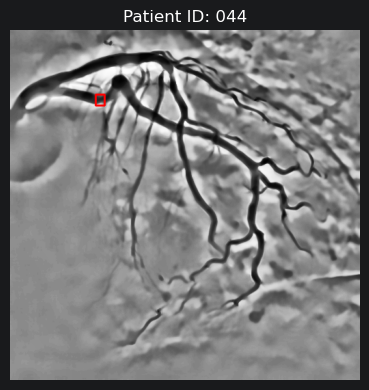

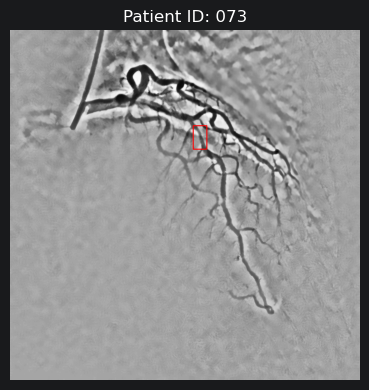

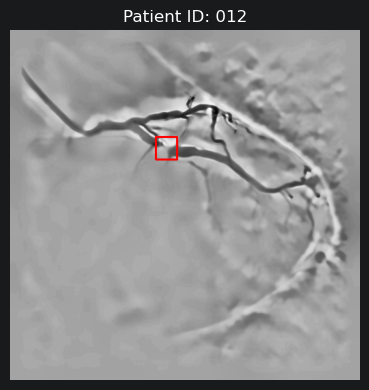

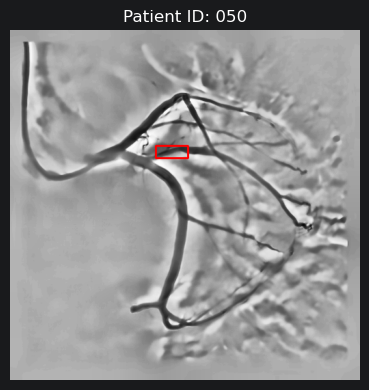

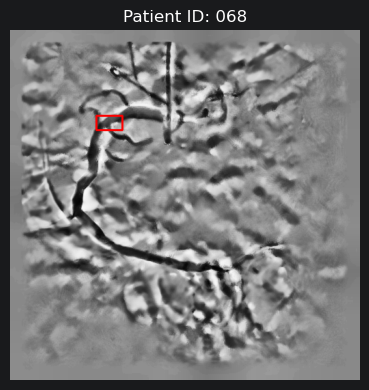

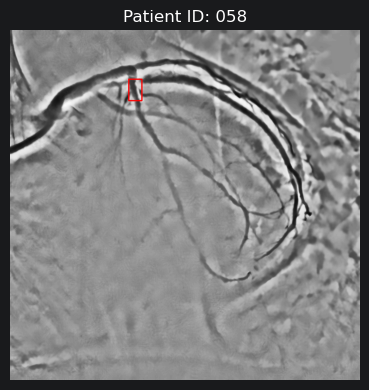

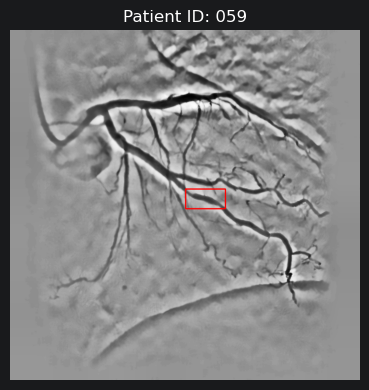

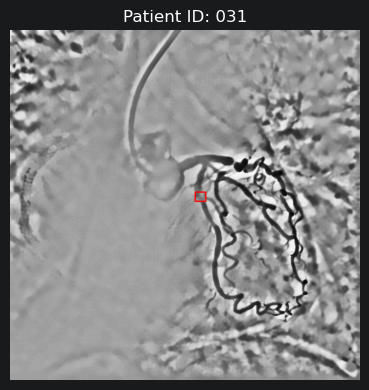

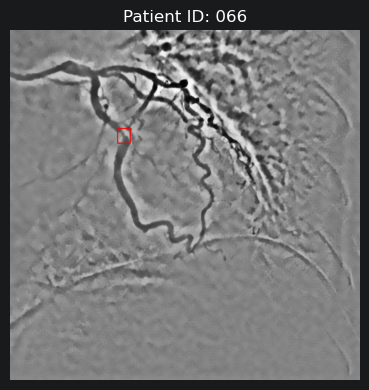

In [10]:
from src.region_visualization import crop_roi
from src.preprocessing import subtract_background, apply_nlm, apply_clahe, _sample_patient_frames
from src.utils import get_xml_path, parse_stenosis_xml, draw_bboxes, im_show

# Same 9 patients as the grids above
loaded = _sample_patient_frames(series, n=9, seed=random.randint(1,99))
for pid, _ in loaded:  # ignore the randomly loaded image
    serie_paths = next(v for k, v in series.items() if k.split('/')[0] == pid)
    path  = serie_paths[len(serie_paths) // 2]  # middle frame
    img   = load_image(path)                     # reload from middle frame
    boxes = parse_stenosis_xml(get_xml_path(path))
    if not boxes:
        print(f'  P{pid}: no annotations found')
        continue
    proc          = preprocess_bs_nlm_clahe(img, kernel_size=KERNEL_SIZE, h=H, clip_limit=CLIP_LIMIT)
    img_annotated = draw_bboxes(proc, boxes)
    im_show(img_annotated, title=f'Patient ID: {pid}', figsize=(4, 4))


It looks like this preprocessing mantains the regions where the stenosis are located, even if it removes smaller vessels.

## Alternative Pipeline: Morphological Bottom-Hat → NLM → CLAHE
Instead of using a linear Gaussian subtraction to remove background structures (ribs/spine), we use a **Bottom-Hat Transform**.

This mathematical morphology operation isolates dark structures (vessels) from a light background.
* **Bonus:** It automatically flips the image contrast so that vessels become **bright ridges on a flat, black background**.

Use the sliders to find the optimal disk radius $r$. It should be just slightly wider than the largest coronary artery branch you want to preserve.

In [11]:
# Make sure to re-import or reload if preprocessing.py was changed externally
# from src.preprocessing import browse_bottomhat_nlm_clahe_grid

browse_bottomhat_nlm_clahe_grid(series, n=9, seed=SEED)

interactive(children=(IntSlider(value=15, description='Disk Radius (r)', layout=Layout(width='450px'), max=45,…

I see no parameter values that give better results than the other approach (BS --> NLM --> CLAHE) so I will stick to the other approach.